## Generate Environment Map of Evenly-Distributed Single-Color Lighting

In [8]:
import numpy as np
import cv2

W, H = 1024, 512

peak_value = 1.0

white = np.full((H, W, 3), peak_value, dtype=np.float32)

cv2.imwrite("white_envmap.hdr", white)

True

In [9]:
W, H = 1024, 512

def make_envmap_bgr(bgr_weights, target_luminance=1.0):
    bgr_weights = np.array(bgr_weights, dtype=np.float32)
    b, g, r = bgr_weights[0], bgr_weights[1], bgr_weights[2]

    current_luminance = 0.0722*b + 0.7152*g + 0.2126*r
    scale = target_luminance / current_luminance
    final_bgr = bgr_weights * scale

    img = np.tile(final_bgr, (H, W, 1)).astype(np.float32)
    return img

# warm ~3000K
warm = make_envmap_bgr((0.54, 0.78, 1.0))
# cool ~8000K
cool = make_envmap_bgr((1.0, 0.82, 0.70))

cv2.imwrite("warm_envmap.hdr", warm)
cv2.imwrite("cool_envmap.hdr", cool)

True

In [5]:
def save_as_png(hdr_img, filename):
    """
    Save generated light maps as png to check
    """
    ldr = np.clip(hdr_img, 0.0, 1.0)
    ldr = np.power(ldr, 1.0 / 2.2)
    ldr_8bit = (ldr * 255.0).astype(np.uint8)
    cv2.imwrite(filename, ldr_8bit)

save_as_png(white, "white_envmap.png")
save_as_png(warm, "warm_envmap.png")
save_as_png(cool, "cool_envmap.png")

In [6]:
import cv2
hdr = cv2.imread("warm_envmap.hdr", cv2.IMREAD_UNCHANGED)

### Filtering Environment Map

Our filtering process follows [this documentation](https://github.com/Pixel-Talk/HRAvatar/blob/main/assets/docs/Filter_Envmap.md) of [HRAvatar](https://github.com/Pixel-Talk/HRAvatar/tree/main).

Special thanks to [cmft](https://github.com/dariomanesku/cmft) and [cmftStudio](https://github.com/dariomanesku/cmftStudio) for providing open-source tools for cubemap filtering.


In [7]:
# Setup

%%bash
git clone https://github.com/dariomanesku/cmft.git
cd cmft

make
make linux-release64

./dependency/bx/tools/bin/linux/genie --file=scripts/main.lua xcode4
Building configurations...
Running action 'xcode4'...
Generating _projects/xcode4/cmft.xcworkspace/contents.xcworkspacedata...
Generating _projects/xcode4/cmft_cli.xcodeproj/project.pbxproj...
Generating _projects/xcode4/cmft.xcodeproj/project.pbxproj...
Done.
./dependency/bx/tools/bin/linux/genie --file=scripts/main.lua vs2008
Building configurations...
Running action 'vs2008'...
Generating _projects/vs2008/cmft.sln...
Generating _projects/vs2008/cmft_cli.vcproj...
Generating _projects/vs2008/cmft_cli.vcproj.user...
Generating _projects/vs2008/cmft.vcproj...
Generating _projects/vs2008/cmft.vcproj.user...
Done.
./dependency/bx/tools/bin/linux/genie --file=scripts/main.lua vs2010
Building configurations...
Running action 'vs2010'...
Generating _projects/vs2010/cmft.sln...
Generating _projects/vs2010/cmft_cli.vcxproj...
Generating _projects/vs2010/cmft_cli.vcxproj.user...
Generating _projects/vs2010/cmft_cli.vcxproj.fi

Cloning into 'cmft'...
In file included from ../../src/cmft/clcontext.cpp:15:
../../src/cmft/common/utils.h: In function ‘cmft::ClContext* cmft::clInit(uint32_t, uint32_t, uint32_t, const char*)’:
../../src/cmft/common/utils.h:193:20: warning: ‘char* __builtin___strncat_chk(char*, const char*, long unsigned int, long unsigned int)’ output may be truncated copying 127 bytes from a string of length 127 [-Wstringop-truncation]
  193 |             strncat(_dst, _src, _dstSize-1);
      |                    ^
../../src/cmft/common/utils.h:193:20: warning: ‘char* __builtin___strncat_chk(char*, const char*, long unsigned int, long unsigned int)’ output may be truncated copying 127 bytes from a string of length 127 [-Wstringop-truncation]
../../src/cmft/common/utils.h: In function ‘void cmft::clPrintDevices()’:
../../src/cmft/common/utils.h:193:20: warning: ‘char* __builtin___strncat_chk(char*, const char*, long unsigned int, long unsigned int)’ output may be truncated copying 31 bytes from a 

In [11]:
# Filtering the Radiance Map
%%bash
CMFT=cmft/_build/linux64_gcc/bin/cmftRelease

$CMFT --input "white_envmap.hdr" \      # Change to "cool", "warm", or any other environment map you generated
      --filter radiance                 \
       --srcFaceSize 256                 \
       --excludeBase false               \
       --mipCount 7                      \
       --generateMipChain false          \
       --glossScale 10                   \
       --glossBias 3                     \
       --lightingModel blinnbrdf         \
       --edgeFixup none                  \
       --dstFaceSize 256                 \
       ::Processing devices              \
       --numCpuProcessingThreads 8       \
       --useOpenCL true                  \
       --clVendor anyGpuVendor           \
       --deviceType gpu                  \
       --deviceIndex 0                   \
       ::Aditional operations            \
       --inputGammaNumerator 1.0         \
       --inputGammaDenominator 1.0       \
       --outputGammaNumerator 1.0        \
       --outputGammaDenominator 1.0      \
       ::Output                          \
       --outputNum 1                     \
       --output0 "specular" \
       --output0params tga,bgr8,latlong

CMFT info: Converting latlong image to cubemap.
CMFT info: Running radiance filter for:
	[srcFaceSize=256]
	[lightingModel=blinnbrdf]
	[excludeBase=false]
	[mipCount=7]
	[glossScale=10]
	[glossBias=3]
	[dstFaceSize=256]
CMFT info: Radiance -> Starting filter...
CMFT info: Radiance -> Utilizing 8 CPU processing threads and Tesla T4.
CMFT info: Radiance -> ------------------------------------
CMFT info: Radiance ->  Device / Face /     Time /    Total
CMFT info: Radiance -> ------------------------------------
CMFT info: Radiance ->  <GPU>  |  256 |   0.197s |   0.204s
CMFT info: Radiance -> [CPU0]  |    4 |   0.237s |   0.237s
CMFT info: Radiance -> [CPU5]  |    4 |   0.268s |   0.273s
CMFT info: Radiance -> [CPU2]  |    4 |   0.275s |   0.275s
CMFT info: Radiance -> [CPU3]  |    4 |   0.277s |   0.280s
CMFT info: Radiance -> [CPU4]  |    4 |   0.282s |   0.286s
CMFT info: Radiance -> [CPU1]  |    4 |   0.288s |   0.288s
CMFT info: Radiance ->  <GPU>  |  256 |   0.167s |   0.371s
CMFT i

In [12]:
# Filtering the Irradiance Map
%%bash
CMFT=cmft/_build/linux64_gcc/bin/cmftRelease

$CMFT --input "white_envmap.hdr" \     # Change to "cool", "warm", or any other environment map you generated
      ::Filter options                  \
       --filter irradiance               \
       --srcFaceSize 256                 \
       --dstFaceSize 128                 \
       ::Aditional operations            \
       --inputGammaNumerator 1.0         \
       --inputGammaDenominator 1.0       \
       --outputGammaNumerator 1.0        \
       --outputGammaDenominator 1.0      \
       ::Output                          \
       --outputNum 1                     \
       --output0 "diffuse"  \
       --output0params tga,bgr8,latlong  \

CMFT info: Converting latlong image to cubemap.
CMFT info: Running irradiance filter for:
	[srcFaceSize=256]
	[shOrder=5]
	[dstFaceSize=128]
CMFT info: Irradiance -> Done! Total time: 0.013 seconds.
CMFT info: Saving diffuse.tga [TGA 512x256 BGR8 LatLong 1-faces 1-mips].
CMFT info: Done.


Validate if it's single color or matched luminance

In [13]:
from PIL import Image
import glob

for path in sorted(glob.glob("*.tga")):
    try:
        arr = np.array(Image.open(path))
        print(f"{path}: shape={arr.shape} min={arr.min()} max={arr.max()} std={arr.std():.4f}")
    except Exception as e:
        print(f"{path}: failed-> {e}")

diffuse.tga: shape=(256, 512, 3) min=254 max=255 std=0.4967
specular_0_1024x512.tga: shape=(512, 1024, 3) min=254 max=255 std=0.3418
specular_1_512x256.tga: shape=(256, 512, 3) min=254 max=255 std=0.2995
specular_2_256x128.tga: shape=(128, 256, 3) min=254 max=255 std=0.3982
specular_3_128x64.tga: shape=(64, 128, 3) min=254 max=255 std=0.3882
specular_4_64x32.tga: shape=(32, 64, 3) min=254 max=255 std=0.2573
specular_5_32x16.tga: shape=(16, 32, 3) min=254 max=255 std=0.4038
specular_6_16x8.tga: shape=(8, 16, 3) min=254 max=255 std=0.3703


In [14]:
def compute_luminance(arr):
    arr_float = arr.astype(np.float32) / 255.0
    b, g, r = arr_float[..., 0], arr_float[..., 1], arr_float[..., 2]
    luminance_coeffs = np.array([0.0722, 0.7152, 0.2126])
    luminance = b * luminance_coeffs[0] + g * luminance_coeffs[1] + r * luminance_coeffs[2]
    return luminance

for path in sorted(glob.glob("*.tga")):
    try:
        img = Image.open(path)
        arr = np.array(img)

        if arr.shape[-1] == 4:
            arr = arr[..., :3]

        luminance = compute_luminance(arr)

        print(f"{path}:")
        print(f"  raw shape={arr.shape}, raw min={arr.min()}, raw max={arr.max()}")
        print(f"  linear luminance: mean={luminance.mean():.4f}, min={luminance.min():.4f}, max={luminance.max():.4f}, std={luminance.std():.4f}")
        print(f"  (expected baseline for white_envmap.hdr: luminance ≈ 1.0)")
        print()
    except Exception as e:
        print(f"{path}: failed-> {e}")

diffuse.tga:
  raw shape=(256, 512, 3), raw min=254, raw max=255
  linear luminance: mean=0.9983, min=0.9961, max=1.0000, std=0.0019
  (expected baseline for white_envmap.hdr: luminance ≈ 1.0)

specular_0_1024x512.tga:
  raw shape=(512, 1024, 3), raw min=254, raw max=255
  linear luminance: mean=0.9995, min=0.9961, max=1.0000, std=0.0013
  (expected baseline for white_envmap.hdr: luminance ≈ 1.0)

specular_1_512x256.tga:
  raw shape=(256, 512, 3), raw min=254, raw max=255
  linear luminance: mean=0.9996, min=0.9961, max=1.0000, std=0.0012
  (expected baseline for white_envmap.hdr: luminance ≈ 1.0)

specular_2_256x128.tga:
  raw shape=(128, 256, 3), raw min=254, raw max=255
  linear luminance: mean=0.9992, min=0.9961, max=1.0000, std=0.0016
  (expected baseline for white_envmap.hdr: luminance ≈ 1.0)

specular_3_128x64.tga:
  raw shape=(64, 128, 3), raw min=254, raw max=255
  linear luminance: mean=0.9993, min=0.9961, max=1.0000, std=0.0015
  (expected baseline for white_envmap.hdr: lumi

## Pre-processing of Environmental Maps Captured in Real-World Scenario

You can download the HDR environment maps you like from [Poly Haven](https://polyhaven.com/hdris), and save them in the same directory as this notebook.

In [15]:
# Setup
!pip install OpenEXR

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.8 MB/s eta 0:00:00


In [29]:
import OpenEXR
import Imath
import cv2

def read_exr(path):
    exr_file = OpenEXR.InputFile(path)
    header = exr_file.header()
    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    channels = ['R', 'G', 'B']
    img = np.zeros((height, width, 3), dtype=np.float32)
    for i, c in enumerate(channels):
        raw = exr_file.channel(c, FLOAT)
        img[..., i] = np.frombuffer(raw, dtype=np.float32).reshape(height, width)
    return img

hdr = read_exr("childrens_hospital_4k.exr") # change to your file name

# resize
target_W, target_H = 1024, 512
hdr_resized = cv2.resize(hdr, (target_W, target_H), interpolation=cv2.INTER_AREA)

r, g, b = hdr_resized[..., 0], hdr_resized[..., 1], hdr_resized[..., 2]
luminance_coeffs = np.array([0.2126, 0.7152, 0.0722])
current_avg_luminance = (r * luminance_coeffs[0] + g * luminance_coeffs[1] + b * luminance_coeffs[2]).mean()

target_luminance = 1.0
scale = target_luminance / current_avg_luminance
hdr_matched = (hdr_resized * scale).astype(np.float32)

cv2.imwrite("matched_public_map.hdr", cv2.cvtColor(hdr_matched, cv2.COLOR_RGB2BGR))

print(f"Original size: {hdr.shape[1]}x{hdr.shape[0]}")
print(f"Resized to: {hdr_matched.shape[1]}x{hdr_matched.shape[0]}")
print(f"Final avg luminance: {(hdr_matched[...,0]*0.2126 + hdr_matched[...,1]*0.7152 + hdr_matched[...,2]*0.0722).mean():.4f}")

Original size: 4096x2048
Resized to: 1024x512
Final avg luminance: 1.0000


In [25]:
def save_as_png(hdr_img, filename):
    ldr = np.clip(hdr_img, 0.0, 1.0)
    ldr = np.power(ldr, 1.0 / 2.2)
    ldr_8bit = (ldr * 255.0).astype(np.uint8)

    ldr_8bit_bgr = cv2.cvtColor(ldr_8bit, cv2.COLOR_RGB2BGR)
    cv2.imwrite(filename, ldr_8bit_bgr)

save_as_png(hdr_matched, "matched_public_envmap.png")

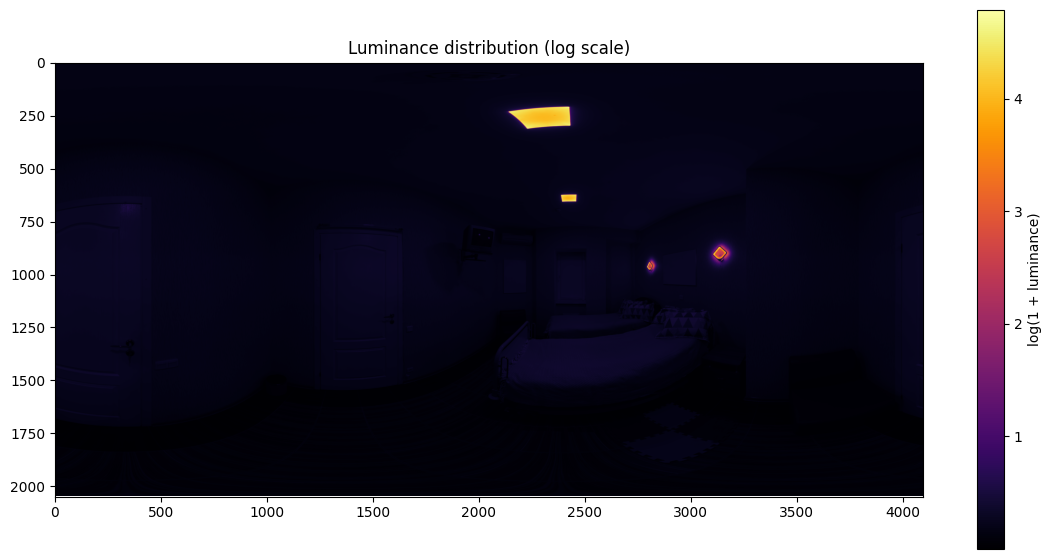

Luminance stats:
  mean: 0.3941
  std:  3.7677
  min:  0.0000
  max:  118.8636
  std/mean ratio: 9.5615


In [26]:
import matplotlib.pyplot as plt

def read_exr(path):
    exr_file = OpenEXR.InputFile(path)
    header = exr_file.header()
    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    channels = ['R', 'G', 'B']
    img = np.zeros((height, width, 3), dtype=np.float32)
    for i, c in enumerate(channels):
        raw = exr_file.channel(c, FLOAT)
        img[..., i] = np.frombuffer(raw, dtype=np.float32).reshape(height, width)
    return img

hdr = read_exr("childrens_hospital_4k.exr") # change to your file name

r, g, b = hdr[..., 0], hdr[..., 1], hdr[..., 2]
luminance = 0.2126*r + 0.7152*g + 0.0722*b

# Visualize downloaded public map
log_luminance = np.log1p(luminance)

plt.figure(figsize=(14, 7))
plt.imshow(log_luminance, cmap='inferno')
plt.colorbar(label='log(1 + luminance)')
plt.title('Luminance distribution (log scale)')
plt.savefig('luminance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Luminance stats:")
print(f"  mean: {luminance.mean():.4f}")
print(f"  std:  {luminance.std():.4f}")
print(f"  min:  {luminance.min():.4f}")
print(f"  max:  {luminance.max():.4f}")
print(f"  std/mean ratio: {luminance.std()/luminance.mean():.4f}")

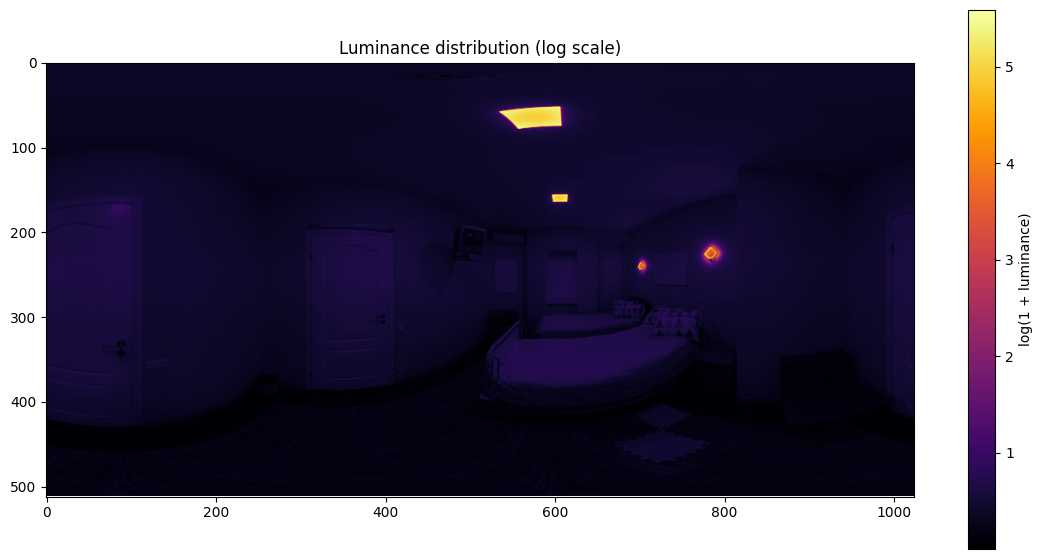

Luminance stats:
  mean: 0.9966
  std:  9.3843
  min:  0.0026
  max:  266.0080
  std/mean ratio: 9.4166


In [27]:
# Visualize the environment map with matched luminance
# Could be compared with the above result

def read_hdr(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_ANYCOLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"cv2 failed to read {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb.astype(np.float32)

hdr = read_hdr("matched_public_map.hdr")

r, g, b = hdr[..., 0], hdr[..., 1], hdr[..., 2]
luminance = 0.2126*r + 0.7152*g + 0.0722*b

log_luminance = np.log1p(luminance)

plt.figure(figsize=(14, 7))
plt.imshow(log_luminance, cmap='inferno')
plt.colorbar(label='log(1 + luminance)')
plt.title('Luminance distribution (log scale)')
plt.savefig('luminance_heatmap_matched.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Luminance stats:")
print(f"  mean: {luminance.mean():.4f}")
print(f"  std:  {luminance.std():.4f}")
print(f"  min:  {luminance.min():.4f}")
print(f"  max:  {luminance.max():.4f}")
print(f"  std/mean ratio: {luminance.std()/luminance.mean():.4f}")

### Filtering Environment Map

The same process as the single-color environment map

In [33]:
# Filtering the Radiance Map
%%bash
CMFT=cmft/_build/linux64_gcc/bin/cmftRelease

$CMFT --input "matched_public_map.hdr" \
      --filter radiance                 \
       --srcFaceSize 256                 \
       --excludeBase false               \
       --mipCount 7                      \
       --generateMipChain false          \
       --glossScale 10                   \
       --glossBias 3                     \
       --lightingModel blinnbrdf         \
       --edgeFixup none                  \
       --dstFaceSize 256                 \
       ::Processing devices              \
       --numCpuProcessingThreads 8       \
       --useOpenCL true                  \
       --clVendor anyGpuVendor           \
       --deviceType gpu                  \
       --deviceIndex 0                   \
       ::Aditional operations            \
       --inputGammaNumerator 1.0         \
       --inputGammaDenominator 1.0       \
       --outputGammaNumerator 1.0        \
       --outputGammaDenominator 1.0      \
       ::Output                          \
       --outputNum 1                     \
       --output0 "specular" \
       --output0params tga,bgr8,latlong

CMFT info: Converting latlong image to cubemap.
CMFT info: Running radiance filter for:
	[srcFaceSize=256]
	[lightingModel=blinnbrdf]
	[excludeBase=false]
	[mipCount=7]
	[glossScale=10]
	[glossBias=3]
	[dstFaceSize=256]
CMFT info: Radiance -> Starting filter...
CMFT info: Radiance -> Utilizing 8 CPU processing threads and Tesla T4.
CMFT info: Radiance -> ------------------------------------
CMFT info: Radiance ->  Device / Face /     Time /    Total
CMFT info: Radiance -> ------------------------------------
CMFT info: Radiance ->  <GPU>  |  256 |   0.185s |   0.194s
CMFT info: Radiance -> [CPU3]  |    4 |   0.206s |   0.208s
CMFT info: Radiance -> [CPU4]  |    4 |   0.207s |   0.210s
CMFT info: Radiance -> [CPU0]  |    4 |   0.213s |   0.213s
CMFT info: Radiance -> [CPU2]  |    4 |   0.236s |   0.238s
CMFT info: Radiance -> [CPU5]  |    4 |   0.239s |   0.243s
CMFT info: Radiance -> [CPU1]  |    4 |   0.244s |   0.244s
CMFT info: Radiance ->  <GPU>  |  256 |   0.178s |   0.372s
CMFT i

In [34]:
# Filtering the Irradiance Map
%%bash
CMFT=cmft/_build/linux64_gcc/bin/cmftRelease

$CMFT --input "matched_public_map.hdr" \
      ::Filter options                  \
       --filter irradiance               \
       --srcFaceSize 256                 \
       --dstFaceSize 128                 \
       ::Aditional operations            \
       --inputGammaNumerator 1.0         \
       --inputGammaDenominator 1.0       \
       --outputGammaNumerator 1.0        \
       --outputGammaDenominator 1.0      \
       ::Output                          \
       --outputNum 1                     \
       --output0 "diffuse"  \
       --output0params tga,bgr8,latlong  \

CMFT info: Converting latlong image to cubemap.
CMFT info: Running irradiance filter for:
	[srcFaceSize=256]
	[shOrder=5]
	[dstFaceSize=128]
CMFT info: Irradiance -> Done! Total time: 0.014 seconds.
CMFT info: Saving diffuse.tga [TGA 512x256 BGR8 LatLong 1-faces 1-mips].
CMFT info: Done.


## You can now download the processed `.png`, `diffuse.tga`, and 7 specular `.tga` files, and place them in one folder for each environment map.